# PCam Histopathology Cancer Detection
## Data Exploration and Preprocessing

This notebook explores the PatchCamelyon (PCam) dataset used for binary histopathology image classification.

The objective is to understand:

- Dataset structure and dimensions
- Tumor vs non-tumor class distribution
- Representative histopathology patches
- Pixel intensity characteristics
- Image normalization requirements
- Data augmentation strategy
- Train, validation, and test split structure

The dataset consists of 96 × 96 RGB histopathology patches extracted from lymph-node sections.

The classification task is:

- **Class 0:** Non-tumor tissue
- **Class 1:** Tumor tissue

The official PCam train, validation, and test splits are used throughout the project.

In [1]:
import os
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torchvision import transforms

## 2. Set Paths and Reproducibility

The PCam files are stored in the project's `data/pcamv1` directory.

A fixed random seed is used so that randomly selected samples can be reproduced.

In [2]:
DATA_DIR = "../data/pcamv1"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Data directory:", DATA_DIR)
print("Directory exists:", os.path.exists(DATA_DIR))

Data directory: ../data/pcamv1
Directory exists: True


## 3. Inspect the Dataset Files

PCam provides separate image and label files for the training, validation, and test sets.

Each split contains:

- `*_x.h5` — RGB image patches
- `*_y.h5` — binary labels

In [3]:
files = sorted(os.listdir(DATA_DIR))

for file in files:
    path = os.path.join(DATA_DIR, file)
    size_mb = os.path.getsize(path) / (1024 ** 2)
    print(f"{file:50s} {size_mb:10.2f} MB")

camelyonpatch_level_2_split_test_x.h5                  864.07 MB
camelyonpatch_level_2_split_test_y.h5                    0.03 MB
camelyonpatch_level_2_split_train_x.h5                6912.52 MB
camelyonpatch_level_2_split_train_y.h5                   0.25 MB
camelyonpatch_level_2_split_valid_x.h5                 864.07 MB
camelyonpatch_level_2_split_valid_y.h5                   0.03 MB


## 4. Define PCam File Paths

The official PCam naming convention is used to construct the paths for each split.

In [4]:
SPLITS = ["train", "valid", "test"]

image_paths = {
    split: os.path.join(
        DATA_DIR,
        f"camelyonpatch_level_2_split_{split}_x.h5"
    )
    for split in SPLITS
}

label_paths = {
    split: os.path.join(
        DATA_DIR,
        f"camelyonpatch_level_2_split_{split}_y.h5"
    )
    for split in SPLITS
}

for split in SPLITS:
    print(f"{split.capitalize()} images:", image_paths[split])
    print(f"{split.capitalize()} labels:", label_paths[split])
    print()

Train images: ../data/pcamv1\camelyonpatch_level_2_split_train_x.h5
Train labels: ../data/pcamv1\camelyonpatch_level_2_split_train_y.h5

Valid images: ../data/pcamv1\camelyonpatch_level_2_split_valid_x.h5
Valid labels: ../data/pcamv1\camelyonpatch_level_2_split_valid_y.h5

Test images: ../data/pcamv1\camelyonpatch_level_2_split_test_x.h5
Test labels: ../data/pcamv1\camelyonpatch_level_2_split_test_y.h5



## 5. Inspect HDF5 Dataset Structure

Before loading the complete dataset into memory, inspect the HDF5 structure and metadata.

This is important because PCam contains hundreds of thousands of images and loading everything into RAM is unnecessary.

In [5]:
for split in SPLITS:
    with h5py.File(image_paths[split], "r") as f:
        print(
            f"{split.upper()} X:",
            f["x"].shape,
            f["x"].dtype
        )

    with h5py.File(label_paths[split], "r") as f:
        print(
            f"{split.upper()} Y:",
            f["y"].shape,
            f["y"].dtype
        )

    print()

TRAIN X: (262144, 96, 96, 3) uint8
TRAIN Y: (262144, 1, 1, 1) uint8

VALID X: (32768, 96, 96, 3) uint8
VALID Y: (32768, 1, 1, 1) uint8

TEST X: (32768, 96, 96, 3) uint8
TEST Y: (32768, 1, 1, 1) uint8



## 6. Dataset Summary

The official PCam dataset contains:

| Split | Samples | Image Size | Channels |
|------|---------|------------|----------|
| Train | 262,144 | 96 × 96 | RGB |
| Validation | 32,768 | 96 × 96 | RGB |
| Test | 32,768 | 96 × 96 | RGB |

The total dataset contains 327,680 image patches.

The original images are stored as unsigned 8-bit RGB pixel values.

In [6]:
dataset_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [262144, 32768, 32768],
    "Image Height": [96, 96, 96],
    "Image Width": [96, 96, 96],
    "Channels": [3, 3, 3]
})

dataset_summary

,Split,Samples,Image Height,Image Width,Channels
0,Train,262144,96,96,3
1,Validation,32768,96,96,3
2,Test,32768,96,96,3


## 7. Examine the Label Distribution

PCam is a binary classification problem.

The labels represent whether the image patch contains tumor tissue.

We inspect the class distribution separately for each official split.

In [7]:
def load_labels(path):
    with h5py.File(path, "r") as f:
        labels = np.array(f["y"])

    return labels.reshape(-1).astype(np.int64)


labels = {
    split: load_labels(label_paths[split])
    for split in SPLITS
}

for split in SPLITS:
    unique, counts = np.unique(labels[split], return_counts=True)

    print(f"\n{split.upper()}")

    for label, count in zip(unique, counts):
        print(
            f"Class {label}: {count:,} "
            f"({count / len(labels[split]) * 100:.2f}%)"
        )


TRAIN
Class 0: 131,072 (50.00%)
Class 1: 131,072 (50.00%)

VALID
Class 0: 16,399 (50.05%)
Class 1: 16,369 (49.95%)

TEST
Class 0: 16,391 (50.02%)
Class 1: 16,377 (49.98%)


In [8]:
class_counts = []

for split in SPLITS:
    counts = np.bincount(labels[split], minlength=2)

    class_counts.append({
        "Split": split.capitalize(),
        "Non-tumor (0)": counts[0],
        "Tumor (1)": counts[1],
        "Total": counts.sum()
    })

class_distribution = pd.DataFrame(class_counts)

class_distribution

,Split,Non-tumor (0),Tumor (1),Total
0,Train,131072,131072,262144
1,Valid,16399,16369,32768
2,Test,16391,16377,32768


## 8. Visualize Class Distribution

A balanced dataset should contain similar numbers of samples from both classes.

This visualization makes the class balance easier to inspect.

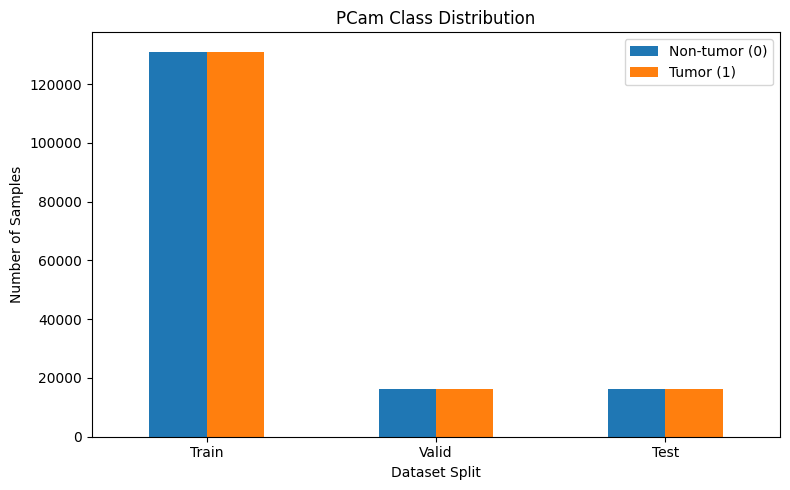

In [9]:
plot_df = class_distribution.set_index("Split")[
    ["Non-tumor (0)", "Tumor (1)"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("PCam Class Distribution")
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 9. Load Representative Samples

The complete PCam dataset is large, so only selected samples are loaded for visualization.

The HDF5 files allow individual images to be accessed without loading the complete dataset into memory.

In [10]:
def load_image(path, index):
    with h5py.File(path, "r") as f:
        image = f["x"][index]

    return image


def get_indices_for_class(labels_array, class_id, n=5):
    indices = np.where(labels_array == class_id)[0]

    rng = np.random.default_rng(SEED)

    selected = rng.choice(
        indices,
        size=min(n, len(indices)),
        replace=False
    )

    return selected

## 10. Visualize Non-Tumor and Tumor Patches

Representative samples from both classes are displayed side by side.

Because histopathology images can contain subtle morphological differences, visual inspection provides an initial understanding of the classification challenge.

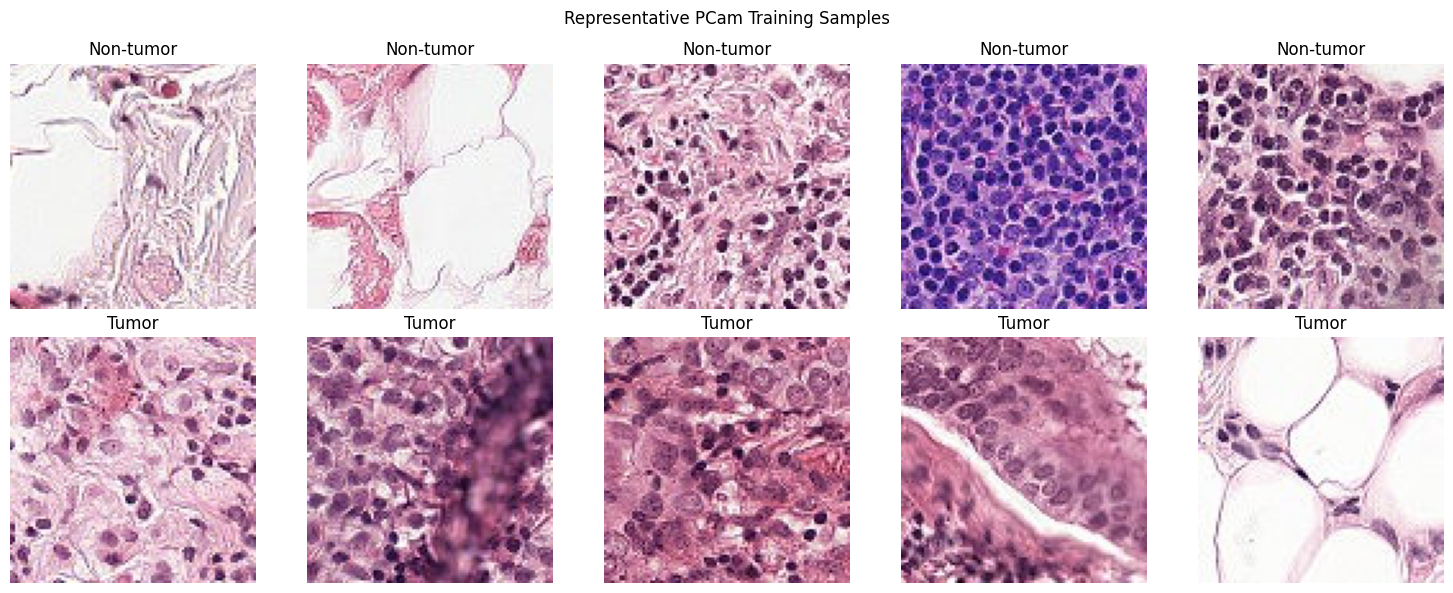

In [11]:
non_tumor_indices = get_indices_for_class(
    labels["train"],
    class_id=0,
    n=5
)

tumor_indices = get_indices_for_class(
    labels["train"],
    class_id=1,
    n=5
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for i, idx in enumerate(non_tumor_indices):
    image = load_image(image_paths["train"], idx)

    axes[0, i].imshow(image)
    axes[0, i].set_title("Non-tumor")
    axes[0, i].axis("off")

for i, idx in enumerate(tumor_indices):
    image = load_image(image_paths["train"], idx)

    axes[1, i].imshow(image)
    axes[1, i].set_title("Tumor")
    axes[1, i].axis("off")

plt.suptitle("Representative PCam Training Samples")
plt.tight_layout()
plt.show()

## 11. Inspect Individual Samples

We can inspect a single patch together with its corresponding label.

This verifies that the image and label indexing are aligned correctly.

In [12]:
sample_index = 100

sample_image = load_image(
    image_paths["train"],
    sample_index
)

sample_label = labels["train"][sample_index]

print("Index :", sample_index)
print("Shape :", sample_image.shape)
print("Dtype :", sample_image.dtype)
print("Label :", sample_label)

Index : 100
Shape : (96, 96, 3)
Dtype : uint8
Label : 1


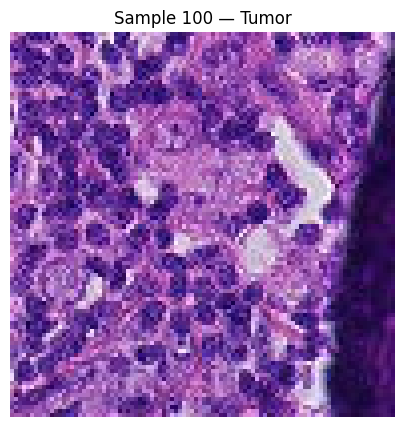

In [13]:
plt.figure(figsize=(5, 5))

plt.imshow(sample_image)

label_name = (
    "Tumor"
    if sample_label == 1
    else "Non-tumor"
)

plt.title(
    f"Sample {sample_index} — {label_name}"
)

plt.axis("off")
plt.show()

## 12. Pixel Intensity Analysis

The original PCam images contain RGB values in the range [0, 255].

We inspect the distribution of pixel intensities using a representative subset rather than the entire dataset.

In [14]:
rng = np.random.default_rng(SEED)

sample_indices = rng.choice(
    len(labels["train"]),
    size=1000,
    replace=False
)

sample_images = np.stack([
    load_image(
        image_paths["train"],
        idx
    )
    for idx in sample_indices
])

print("Sample batch shape:", sample_images.shape)
print("Minimum pixel value:", sample_images.min())
print("Maximum pixel value:", sample_images.max())
print("Mean pixel value:", sample_images.mean())
print("Standard deviation:", sample_images.std())

Sample batch shape: (1000, 96, 96, 3)
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 163.15464695457175
Standard deviation: 64.60674691301213


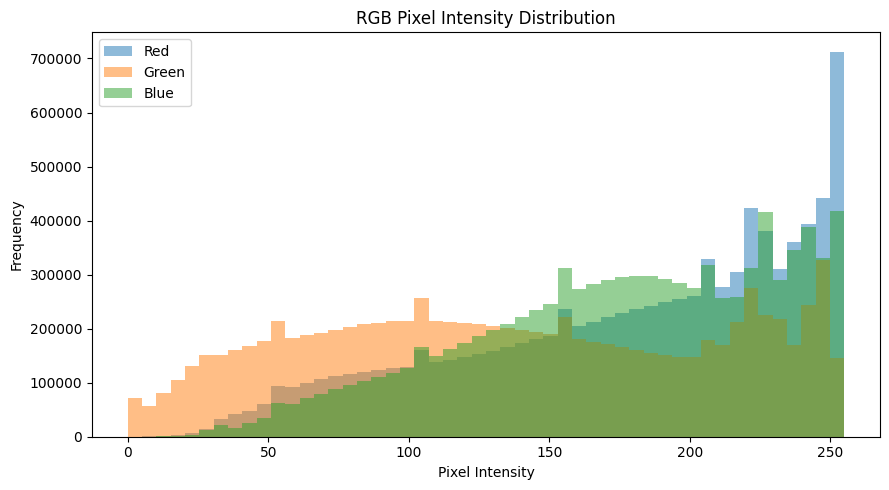

In [15]:
pixels = sample_images.reshape(-1, 3)

channel_names = ["Red", "Green", "Blue"]

plt.figure(figsize=(9, 5))

for channel in range(3):
    plt.hist(
        pixels[:, channel],
        bins=50,
        alpha=0.5,
        label=channel_names[channel]
    )

plt.title("RGB Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

## 13. Channel Statistics

We calculate the mean and standard deviation of each RGB channel.

These statistics help understand the color distribution of the histopathology patches.

The model training pipeline uses ImageNet normalization because the classifiers use ImageNet-pretrained backbones.

In [16]:
channel_means = sample_images.mean(axis=(0, 1, 2))
channel_stds = sample_images.std(axis=(0, 1, 2))

channel_stats = pd.DataFrame({
    "Channel": ["Red", "Green", "Blue"],
    "Mean": channel_means,
    "Std": channel_stds
})

channel_stats

,Channel,Mean,Std
0,Red,177.892636,59.807588
1,Green,136.007996,70.074253
2,Blue,175.563309,54.098271


## 14. Why Image Normalization?

The PCam images are stored as uint8 values in the range [0, 255].

For neural network training, the images are converted to floating-point tensors and normalized.

The current training pipeline uses ImageNet normalization:

- Mean = [0.485, 0.456, 0.406]
- Standard deviation = [0.229, 0.224, 0.225]

This is appropriate because the ResNet and EfficientNet backbones are initialized using ImageNet-pretrained weights.

Normalization makes the input distribution compatible with the pretrained feature extractor.

## 15. Image Resizing

PCam images are originally 96 × 96 pixels.

The current training pipeline resizes them to 128 × 128 pixels before passing them to the CNN.

This provides a consistent input resolution while keeping CPU memory and computation lower than larger resolutions such as 224 × 224.

In [17]:
sample_pil = Image.fromarray(sample_image)

resize_transform = transforms.Resize(
    (128, 128)
)

resized_image = resize_transform(sample_pil)

print("Original size:", sample_pil.size)
print("Resized size :", resized_image.size)

Original size: (96, 96)
Resized size : (128, 128)


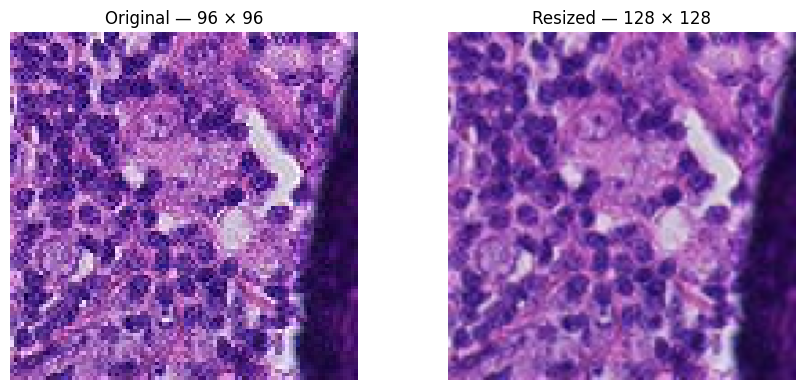

In [18]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4)
)

axes[0].imshow(sample_pil)
axes[0].set_title("Original — 96 × 96")
axes[0].axis("off")

axes[1].imshow(resized_image)
axes[1].set_title("Resized — 128 × 128")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 16. Data Augmentation Strategy

Histopathology images can exhibit variation in:

- Tissue orientation
- Rotation
- Color and staining
- Local appearance
- Tissue positioning

The training pipeline therefore applies spatial and color augmentations.

Current training augmentations include:

- Horizontal flipping
- Vertical flipping
- Random 90° rotations
- Small spatial transformations
- Color jitter

Validation and test images are not augmented because evaluation should measure performance on the original image distribution.

In [19]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
])

augmented_images = [
    train_transform(sample_pil)
    for _ in range(5)
]

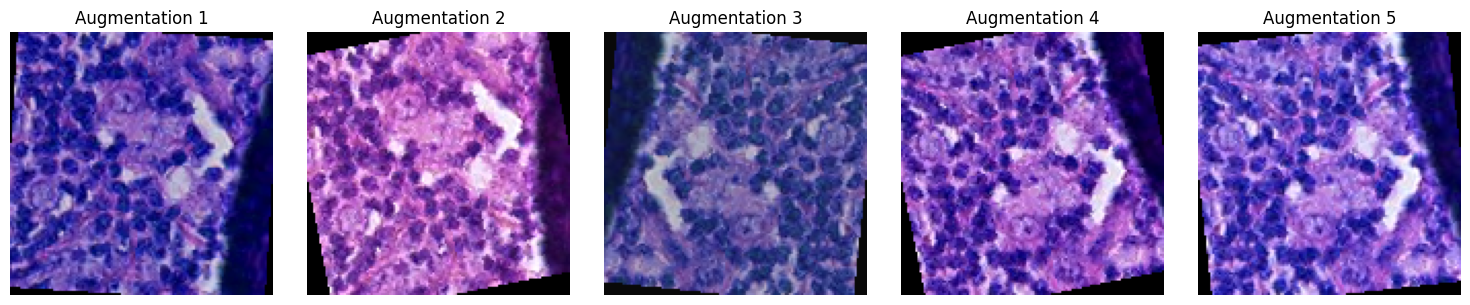

In [20]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 3)
)

for i, image in enumerate(augmented_images):
    axes[i].imshow(image)
    axes[i].set_title(f"Augmentation {i + 1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 17. Validation/Test Preprocessing

Validation and test images use deterministic preprocessing.

No random augmentation is applied during evaluation.

The preprocessing pipeline consists of:

1. Resize to 128 × 128
2. Convert to tensor
3. Normalize using ImageNet statistics

In [21]:
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

normalized_tensor = val_transform(sample_pil)

print("Tensor shape:", normalized_tensor.shape)
print("Tensor dtype:", normalized_tensor.dtype)
print("Minimum:", normalized_tensor.min().item())
print("Maximum:", normalized_tensor.max().item())

Tensor shape: torch.Size([3, 128, 128])
Tensor dtype: torch.float32
Minimum: -2.0357141494750977
Maximum: 2.640000104904175


## 18. Train / Validation / Test Protocol

The project uses the official PCam splits:

- **Training set:** 262,144 patches
- **Validation set:** 32,768 patches
- **Test set:** 32,768 patches

The test set remains completely untouched during model development.

The validation set is used for:

- Model selection
- Hyperparameter monitoring
- Checkpoint selection

The test set is used only for the final evaluation of the selected model.

This separation prevents information from the test set from influencing model development.

## 19. Preprocessing Pipeline Summary

The complete preprocessing pipeline is:

```text
PCam HDF5
    │
    ▼
96 × 96 RGB patch
    │
    ├── Training
    │      ├── Resize → 128 × 128
    │      ├── Spatial augmentation
    │      ├── Color augmentation
    │      ├── ToTensor
    │      └── ImageNet normalization
    │
    └── Validation / Test
           ├── Resize → 128 × 128
           ├── ToTensor
           └── ImageNet normalization